# Data gathering

In [11]:
import sys
import os

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

from data_gathering.gather_robot_data import *
from data_gathering.depth_filtering import *
from shared.aruco_charuco_detection import MarkerDetectionConfig


output_folder = "../example_datasets"

In [12]:
positions_file = "../data_gathering/positions_panda_63.csv"

from data_gathering.robot_interface import gather_robot_data

proto_data = gather_robot_data(
    number_of_positions = None,
    stabilisation_timeout= 1.0,
    position_file = positions_file,
    depth_filter_config=DepthOptimisationConfig()
)

moving to position 0 : [-0.36198  -0.049747  0.033045 -1.6585    0.20059   1.6262    0.35139 ]
JOINT_POSITION
moving to position 1 : [-0.199427  -0.303889   0.0692703 -2.43281    0.0363531  1.98839
  0.840368 ]
JOINT_POSITION
moving to position 2 : [-0.338833 -0.111088 -0.288847 -2.20117   0.307392  1.73006   0.645364]
JOINT_POSITION
moving to position 3 : [-0.22489    0.532639  -0.192103  -1.35517    0.13621    1.31752
  0.0115306]
JOINT_POSITION
moving to position 4 : [ 0.277271   0.54268   -0.209407  -1.42414   -0.0531952  1.39126
  1.88619  ]
JOINT_POSITION
moving to position 5 : [ 0.317017 -0.139508  0.109578 -2.12047  -0.397975  1.83889   2.40216 ]
JOINT_POSITION
moving to position 6 : [ 0.27664   -0.600108   0.0578287 -2.37475   -0.554525   1.72298
 -0.0554051]
JOINT_POSITION
moving to position 7 : [ 0.0382363 -0.37407   -0.0369735 -1.61362   -0.139072   1.22564
  0.876148 ]
JOINT_POSITION
moving to position 8 : [ 1.04209  -0.82438  -0.866144 -1.86998  -0.341921  1.16218   0.733

nothing detected
nothing detected
Using aruco markers for gripper_T_cam determination


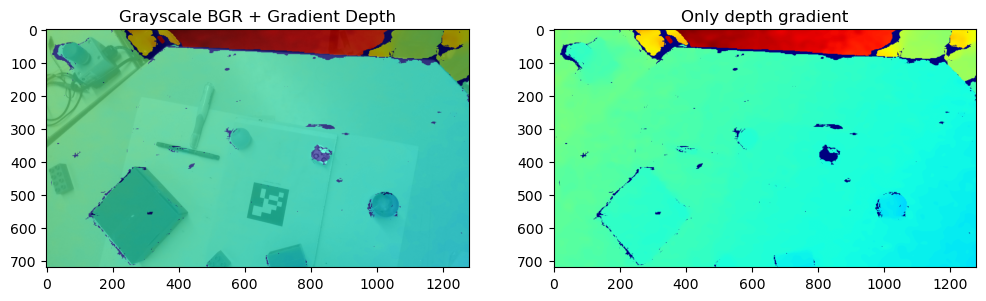

could not find folder data for analysis storage


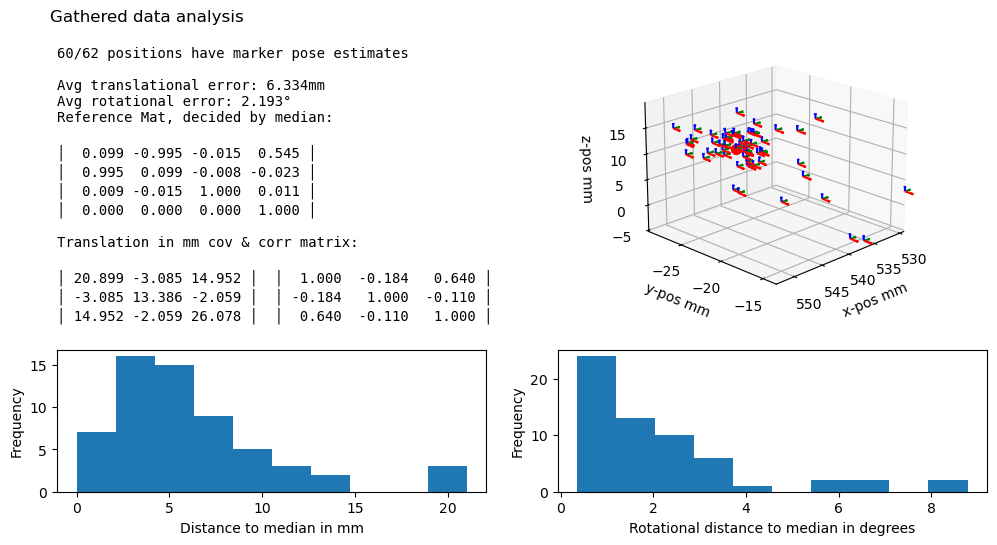

In [16]:
small_aruco =  MarkerDetectionConfig(
    marker_type= "Aruco",
    marker_side_length = 0.0725,
    aruco_marker_dictionary= "6X6_250"
)

gathered_robot_data_small_aruco = optimize_robot_data(
    proto_data=proto_data,
    gripper_t_cam=None,
    marker_detector = MarkerDetector.from_config(small_aruco),
    base_t_gripper_outlier_quantiles=(0.0, 0.0),
)
gathered_robot_data_small_aruco.see_color_depth_alignment()
check_output_data(gathered_data = gathered_robot_data_small_aruco, use_mean = False, save_result = False)
gathered_robot_data_small_aruco.save(folder=output_folder, new_name="small_aruco_2")
